In [1966]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [1967]:
df = pd.read_csv('tvmarketing.csv')
df.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [1968]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [1969]:
df.describe()

,TV,Sales
count,200.000000,200.000000
mean,147.042500,14.022500
std,85.854236,5.217457
min,0.700000,1.600000
25%,74.375000,10.375000
50%,149.750000,12.900000
75%,218.825000,17.400000
max,296.400000,27.000000


In [1970]:
df.isna().sum()

TV       0
Sales    0
dtype: int64

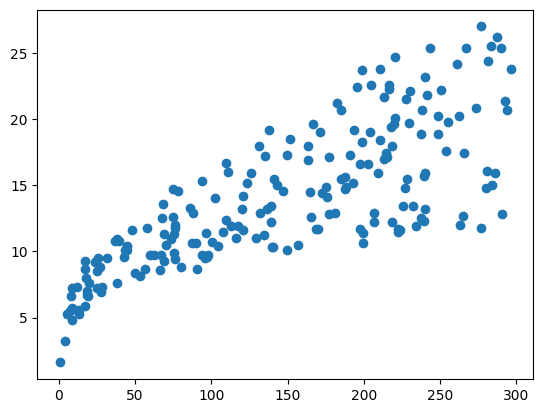

In [1971]:
plt.scatter(x= df['TV'],y = df['Sales'])

(array([26., 15., 21., 18., 19., 17., 22., 26., 20., 16.]),
 array([  0.7 ,  30.27,  59.84,  89.41, 118.98, 148.55, 178.12, 207.69,
        237.26, 266.83, 296.4 ]),
 <BarContainer object of 10 artists>)

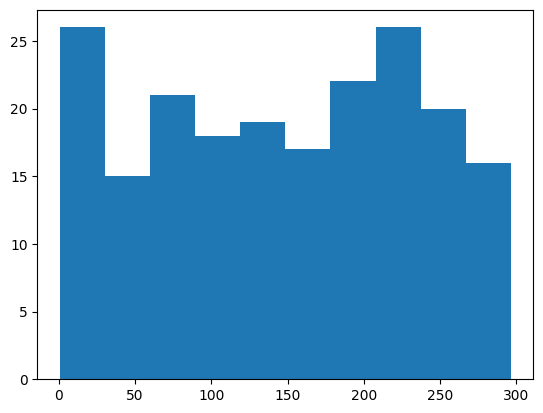

In [1972]:
plt.hist(df['TV'])

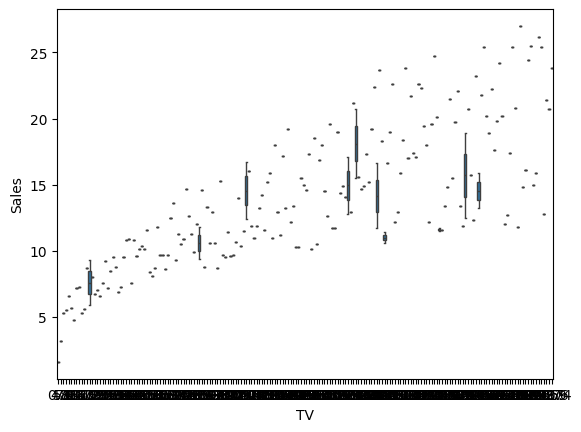

In [1973]:
sns.boxplot(x = 'TV',y = 'Sales',data= df)
plt.show()

In [1974]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [1975]:
X_train,X_test,Y_train,Y_test = train_test_split(x,y, test_size=0.3, random_state=42)

In [1976]:
# check the shape of all the variables
for i in X_train,X_test,Y_train,Y_test:
    print (i.shape)

(140, 1)
(60, 1)
(140,)
(60,)


In [1977]:
# x_test if for testing with y pred

In [1978]:
Le_model = LinearRegression()
Le_model 
## model is not fitted currently and blank instance currently
# once we fit the training data it will evaluate the coefficeint and slope y = mx + c

LinearRegression()

In [1979]:
# train the model
Le_model.fit(X_train,Y_train)

LinearRegression()

In [1980]:
print('The model coeficient / slope is : ',Le_model.coef_) # m from y = mx+c

The model coeficient / slope is :  [0.0464078]


In [1981]:
print ('The model intercept is : ', Le_model.intercept_) # c from y = mx+c

The model intercept is :  7.239459830751138


In [1982]:
# sales_predicted = 0.0464078 * TV + 7.239459830751138
0.0464078 * 44.5 + 7.239459830751138 # (manually)

9.304606930751138

In [1983]:
# check the prediction on the trained data 

Y_train_pred = Le_model.predict(X_train)
Y_test_pred = Le_model.predict(X_test)


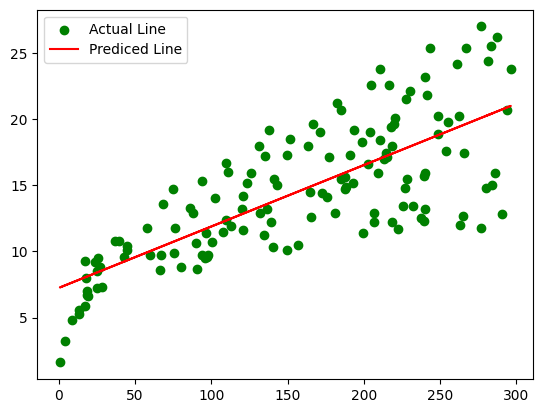

In [1984]:

plt.scatter(X_train,Y_train, color = 'green', label = 'Actual Line')
plt.plot(X_train,Y_train_pred, color = 'red', label = 'Prediced Line')
plt.legend()
plt.show()

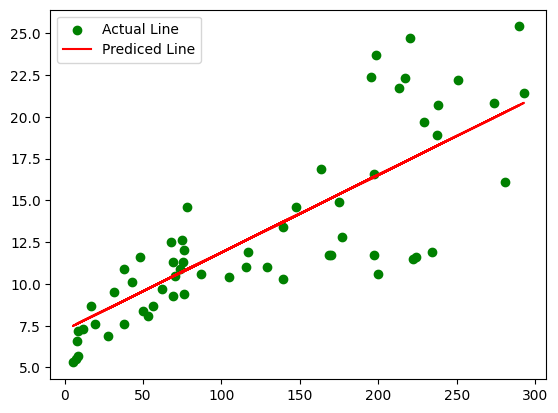

In [1985]:

plt.scatter(X_test,Y_test, color = 'green', label = 'Actual Line')
plt.plot(X_test,Y_test_pred, color = 'red', label = 'Prediced Line')
plt.legend()
plt.show()

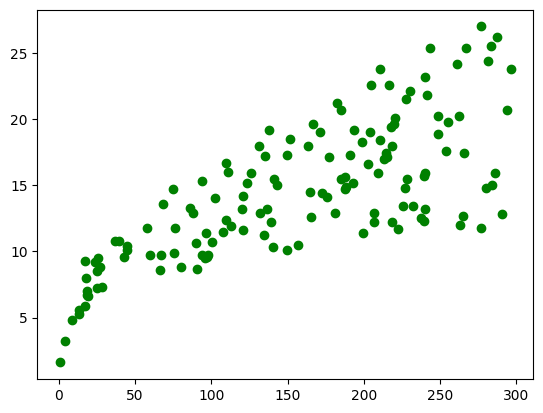

In [1986]:
plt.scatter(X_train,Y_train, color = 'green')

In [1987]:
pd.DataFrame([Y_train_pred,Y_test_pred]).transpose()

,0,1
0,20.433198,14.817854
1,15.820262,16.307544
2,12.478901,20.832305
3,8.343966,7.782431
4,20.730208,17.463099
...,...,...
135,8.399655,NaN
136,16.711292,NaN
137,17.342438,NaN
138,14.924592,NaN


In [1988]:
from sklearn.metrics import r2_score,mean_squared_error

print (r2_score(Y_test,Y_test_pred)) # actual data with the preditction data

0.6714477229302764


In [1989]:
# IF YOU INCLUDE THE BIAS IS TRUE THEN IT WILL TAKE ONLY ONE SINGLE COLUMN WITH THE DEGREE ZERO WHERE ADDITIONAL ONE COLUMN WILL ADD WITH THE VALUES 1
from sklearn.preprocessing import PolynomialFeatures
poly_features =PolynomialFeatures(degree=5, include_bias=True)
# poly_features.fit(X_train)
x_poly_train = poly_features.fit_transform(X_train)
x_poly_test = poly_features.fit_transform(X_test)

In [1990]:
pd.DataFrame(x_poly_train).head()

,0,1,2,3,4,5
0,1.0,284.3,80826.49,2.297897e+07,6.532921e+09,1.857310e+12
1,1.0,184.9,34188.01,6.321363e+06,1.168820e+09,2.161148e+11
2,1.0,112.9,12746.41,1.439070e+06,1.624710e+08,1.834297e+10
3,1.0,23.8,566.44,1.348127e+04,3.208543e+05,7.636332e+06
4,1.0,290.7,84506.49,2.456604e+07,7.141347e+09,2.075990e+12


In [1991]:
liner_poly_reg = LinearRegression()
liner_poly_reg

LinearRegression()

In [1992]:
liner_poly_reg.fit(x_poly_train,Y_train)

LinearRegression()

In [1993]:
print ('Coefficient is:', liner_poly_reg.coef_)
print ('Intercept is:', liner_poly_reg.intercept_)

Coefficient is: [ 0.00000000e+00  3.22417487e-01 -4.89112143e-03  3.83173292e-05
 -1.35719736e-07  1.76100134e-10]
Intercept is: 2.493486926972988


In [1994]:
y_test_poly_pred = liner_poly_reg.predict(x_poly_test)
y_train_poly_pred = liner_poly_reg.predict(x_poly_train)

In [1995]:
pd.DataFrame([y_train_poly_pred,y_test_poly_pred]).transpose()

,0,1
0,19.743492,15.510303
1,16.534425,16.925908
2,12.871172,20.886551
3,7.870861,5.655091
4,20.553989,17.526675
...,...,...
135,8.044386,NaN
136,17.187025,NaN
137,17.483524,NaN
138,15.630035,NaN


In [1996]:
print(f'r2_score for test is : {r2_score(Y_test,y_test_poly_pred):.4f}')
print(f'r2_score for train is : {r2_score(Y_train,y_train_poly_pred):.4f}')

r2_score for test is : 0.6551
r2_score for train is : 0.6022


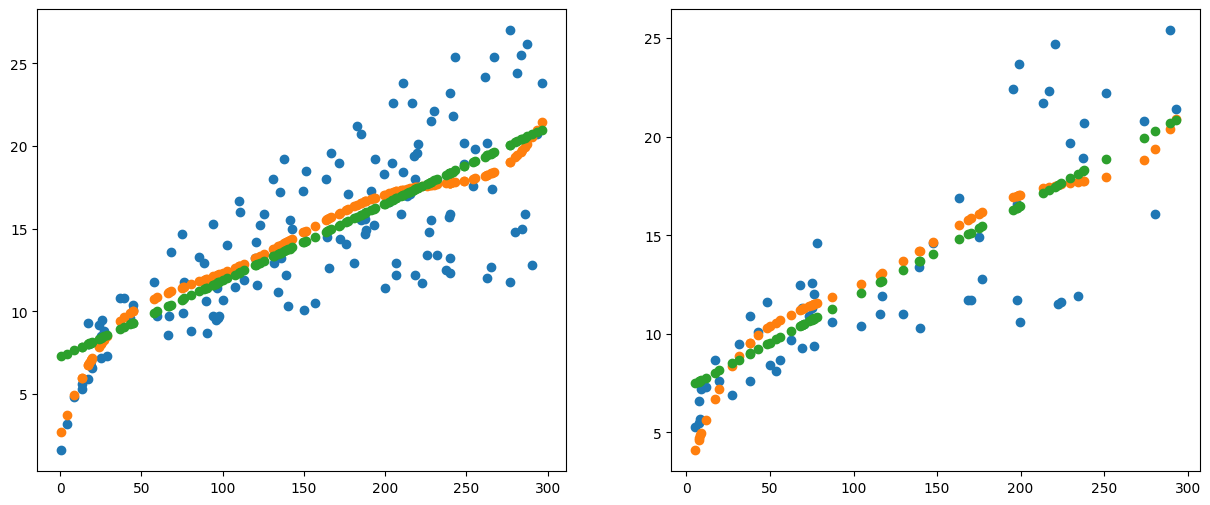

In [1997]:
plt.figure(figsize = (15,6))
plt.subplot(1,2,1)
plt.scatter(X_train,Y_train, label = 'Actuals')
plt.scatter(X_train,y_train_poly_pred)
plt.scatter(X_train,Y_train_pred)

plt.subplot(1,2,2)
plt.scatter(X_test,Y_test, label = 'Actuals')
plt.scatter(X_test,y_test_poly_pred)
plt.scatter(X_test,Y_test_pred)
plt.show()

In [1998]:
print (f'Mean Squared error is : {mean_squared_error(Y_test,y_test_poly_pred):.4f}')
print (f'Mean Squared error is : {mean_squared_error(Y_train,y_train_poly_pred):.4f}')

Mean Squared error is : 9.4170
Mean Squared error is : 10.4389


In [1999]:
## perfromance Metrics:

''' 

    1. Mean Squared Error
    2. Root Mean squared error
    3. Mean absolute error 
    4. R squared :  R2 score

'''

' \n\n    1. Mean Squared Error\n    2. Root Mean squared error\n    3. Mean absolute error \n    4. R squared :  R2 score\n\n'

In [2000]:
## Input are all except the median_house _value

In [2001]:
from sklearn.model_selection import cross_val_score,KFold

In [2002]:
df = pd.read_csv('housing_with_ocean_proximity.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2003]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [2004]:
df.shape

(20640, 10)

In [2005]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [2006]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [2007]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


<Axes: xlabel='longitude', ylabel='latitude'>

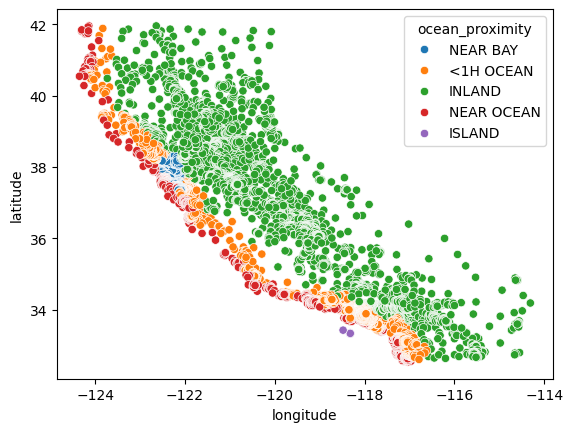

In [2008]:
sns.scatterplot(x = 'longitude',y = 'latitude', hue = 'ocean_proximity', data=df)

In [2009]:
# do one hot encoding

df = pd.get_dummies(df, drop_first= True , prefix='op',dtype ='int')

In [2010]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   op_INLAND           20640 non-null  int32  
 10  op_ISLAND           20640 non-null  int32  
 11  op_NEAR BAY         20640 non-null  int32  
 12  op_NEAR OCEAN       20640 non-null  int32  
dtypes: float64(9), int32(4)
memory usage: 1.7 MB


In [2011]:
## Feature and target split

x = df.drop(columns=['median_house_value'])
y = df['median_house_value']

In [2012]:
# perform the train test split

X_train,X_test,Y_train,Y_test = train_test_split(x,y,random_state=3, test_size=0.3)

In [2013]:
# now the standardization required 

X_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,op_INLAND,op_ISLAND,op_NEAR BAY,op_NEAR OCEAN
215,-122.22,37.79,38.0,3049.0,711.0,2167.0,659.0,2.7969,0,0,1,0
1241,-121.91,39.03,48.0,1096.0,218.0,657.0,199.0,2.7841,1,0,0,0
4922,-118.25,34.00,41.0,1768.0,475.0,1721.0,474.0,1.3030,0,0,0,0
4852,-118.31,34.03,47.0,1315.0,NaN,785.0,245.0,1.2300,0,0,0,0
17711,-121.81,37.33,4.0,5532.0,778.0,3651.0,770.0,7.2982,0,0,0,0


In [2014]:
## HW prdeict with Linear Regression models

## Lasso & Ridge Techniques


In [2015]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, ridge_regression, LassoCV, RidgeCV

In [2016]:
df = pd.read_csv('hitters.csv')
df.head()

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N


#### EDA

In [2017]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  322 non-null    object 
 1   AtBat       322 non-null    int64  
 2   Hits        322 non-null    int64  
 3   HmRun       322 non-null    int64  
 4   Runs        322 non-null    int64  
 5   RBI         322 non-null    int64  
 6   Walks       322 non-null    int64  
 7   Years       322 non-null    int64  
 8   CAtBat      322 non-null    int64  
 9   CHits       322 non-null    int64  
 10  CHmRun      322 non-null    int64  
 11  CRuns       322 non-null    int64  
 12  CRBI        322 non-null    int64  
 13  CWalks      322 non-null    int64  
 14  League      322 non-null    object 
 15  Division    322 non-null    object 
 16  PutOuts     322 non-null    int64  
 17  Assists     322 non-null    int64  
 18  Errors      322 non-null    int64  
 19  Salary      263 non-null    f

In [2018]:
df.duplicated().sum()

0

In [2019]:
df.isna().sum() 

Unnamed: 0     0
AtBat          0
Hits           0
HmRun          0
Runs           0
RBI            0
Walks          0
Years          0
CAtBat         0
CHits          0
CHmRun         0
CRuns          0
CRBI           0
CWalks         0
League         0
Division       0
PutOuts        0
Assists        0
Errors         0
Salary        59
NewLeague      0
dtype: int64

In [2020]:
df.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


In [2021]:
# drop the column unnammed

df.drop(columns=['Unnamed: 0'], inplace=True)

In [2022]:
df.shape

(322, 20)

In [2023]:
## salary having the missing values check the percentage of the salary have missing 

print (f'salary missing percentage {df['Salary'].isna().sum()/df.shape[0]*100:.2f}%')

salary missing percentage 18.32%


In [2024]:
# df['Salary'].fillna(df['Salary'].median(), inplace=True)

In [2025]:
from sklearn.impute import SimpleImputer
si = SimpleImputer(strategy='median')
df['Salary'] = si.fit_transform(df[['Salary']]).flatten()


<Axes: xlabel='Salary', ylabel='Count'>

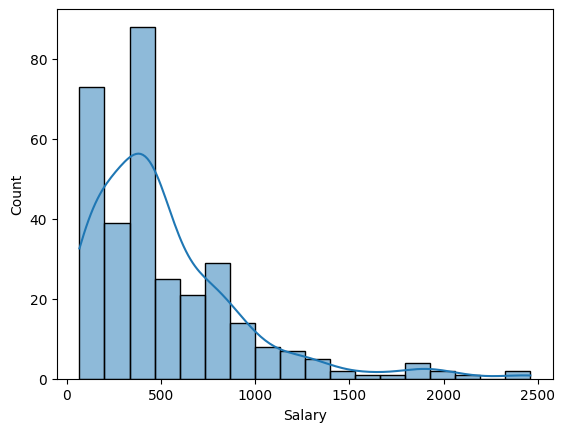

In [2026]:
sns.histplot(x = df['Salary'],data = df, kde= True)

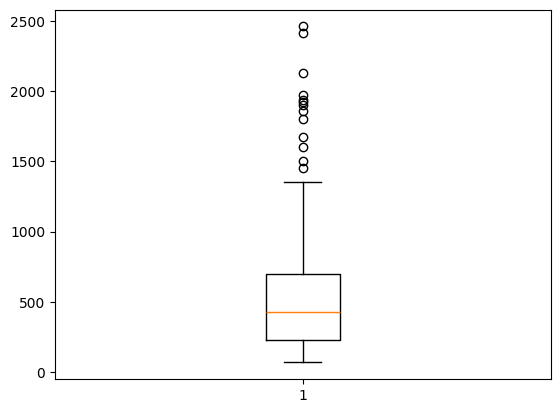

In [2027]:
plt.boxplot(df['Salary'])
plt.show()

In [2028]:
# outliers present but no need to did the winsorazitation because it is a target varriable

In [2029]:
df.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,515.600953
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,409.817459
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,226.250000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,700.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


In [2030]:
# now try to plot and see the correlation matrix
df.select_dtypes(include='object')


,League,Division,NewLeague
0,A,E,A
1,N,W,N
2,A,W,A
3,N,E,N
4,N,E,N
...,...,...,...
317,N,E,N
318,A,E,A
319,A,W,A
320,A,E,A


In [2031]:
# check the unique data from the object column

print (df['League'].unique())
print(df['Division'].unique())
print(df['NewLeague'].unique())

['A' 'N']
['E' 'W']
['A' 'N']


In [2032]:
# using the label encoding do the encoding for the object data

# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# df['League'] = le.fit_transform(df['League'])
# df['Division'] = le.fit_transform(df['Division'])
# df['NewLeague'] = le.fit_transform(df['NewLeague'])

df = pd.get_dummies(df, drop_first = True, dtype =  'int')

In [2033]:
''' 
if you do the onehot encoding then it will increase the column size but also we implemented then the more number of zero ,null and empty
then Sparse Data will made in the data set
'''

' \nif you do the onehot encoding then it will increase the column size but also we implemented then the more number of zero ,null and empty\nthen Sparse Data will made in the data set\n'

In [2034]:
df.isna().sum()

AtBat          0
Hits           0
HmRun          0
Runs           0
RBI            0
Walks          0
Years          0
CAtBat         0
CHits          0
CHmRun         0
CRuns          0
CRBI           0
CWalks         0
PutOuts        0
Assists        0
Errors         0
Salary         0
League_N       0
Division_W     0
NewLeague_N    0
dtype: int64

In [2035]:
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W,NewLeague_N
0,293,66,1,30,29,14,1,293,66,1,30,29,14,446,33,20,425.0,0,0,0
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0,1,1,1
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0,0,1,0
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0,1,0,1
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5,1,0,1


#### Train the model

In [2036]:
x = df.drop(columns=['Salary'])
y = df['Salary']

In [2037]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=25)

In [2038]:
x_train.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
count,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000,257.000000
mean,381.813230,101.894942,10.789883,51.428016,48.182879,38.354086,7.474708,2672.595331,727.225681,68.568093,360.918288,331.961089,255.159533,291.587549,100.311284,7.961089,0.431907,0.521401,0.435798
std,158.430967,47.777649,8.714359,26.926471,26.501799,22.067437,5.004719,2360.794579,669.718075,85.226561,337.489417,336.397514,257.396706,286.720644,134.021149,6.455258,0.496308,0.500517,0.496828
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,246.000000,63.000000,4.000000,30.000000,29.000000,22.000000,4.000000,805.000000,209.000000,14.000000,102.000000,88.000000,65.000000,109.000000,6.000000,3.000000,0.000000,0.000000,0.000000
50%,381.000000,100.000000,8.000000,49.000000,45.000000,34.000000,6.000000,1968.000000,543.000000,36.000000,247.000000,230.000000,166.000000,220.000000,33.000000,6.000000,0.000000,1.000000,0.000000
75%,520.000000,138.000000,17.000000,70.000000,65.000000,53.000000,11.000000,3949.000000,1066.000000,90.000000,544.000000,435.000000,337.000000,325.000000,152.000000,11.000000,1.000000,1.000000,1.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.000000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,1.000000,1.000000,1.000000


#### Input features are not standardize make standardize with the Standard Scaller or numpy

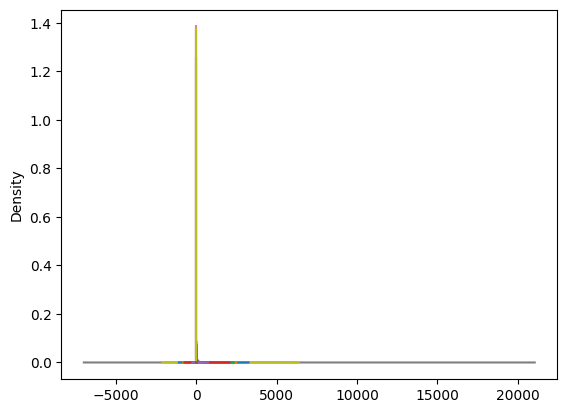

In [2039]:
## check the standardize 
x_train.plot.kde(legend = False)
plt.show()
## data appers the near normal distribution but in KDE plot that the data is not is standardized form hence use standard scaler to standardize the data

In [2040]:
## shallow copied the data 
xtrain_copy = x_train.copy()
x_test_copy = x_test.copy()

<Axes: ylabel='Density'>

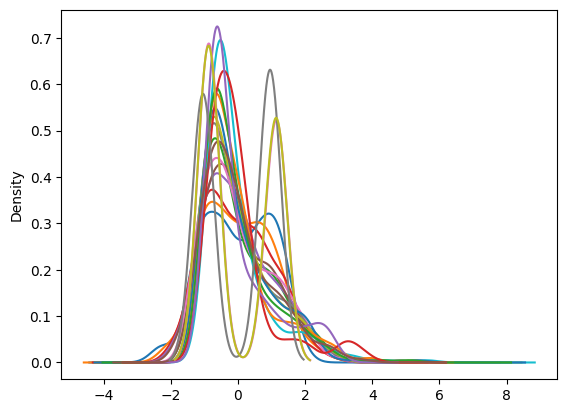

In [2041]:
X_mean = xtrain_copy.mean()
X_std = xtrain_copy.std()

xtrain_copy = (xtrain_copy - X_mean) / X_std
pd.DataFrame(xtrain_copy, columns=  xtrain_copy.columns).plot.kde(legend = False)

In [2042]:
## using the scikit learn

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.fit_transform(x_test)


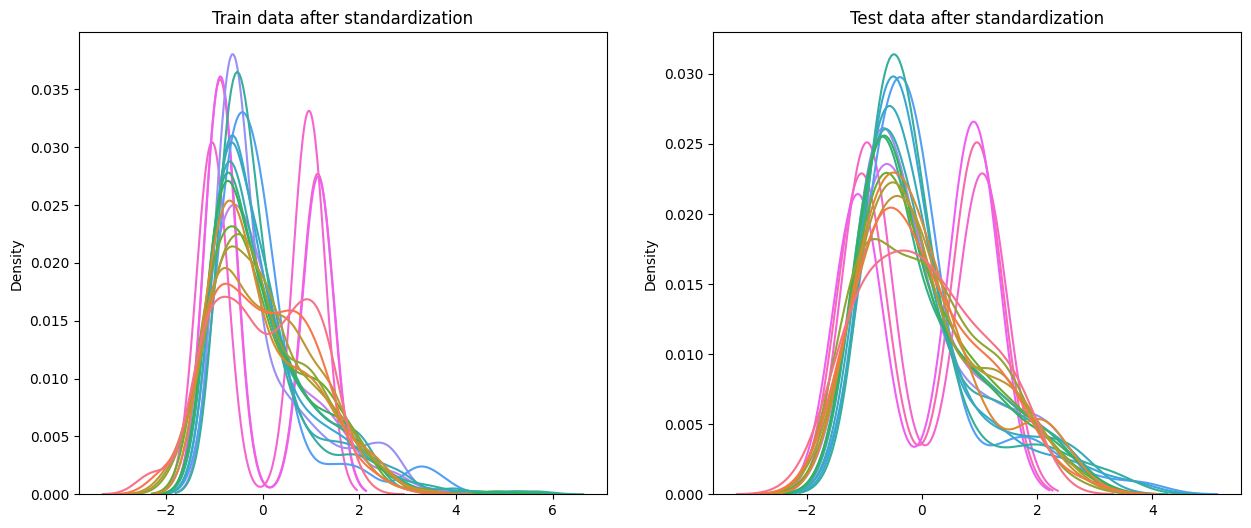

In [2043]:
plt.figure(figsize = (15,6))
plt.subplot(1,2,1)
plt.title('Train data after standardization')
sns.kdeplot(x_train_sc, legend= False)


plt.subplot(1,2,2)
plt.title('Test data after standardization')
sns.kdeplot(x_test_sc,legend = False)
plt.show()

In [2044]:
# pick the model
Linear_model = LinearRegression()
Linear_model


LinearRegression()

In [2045]:
Linear_model.fit(x_train_sc,y_train)

LinearRegression()

In [2046]:
y_pred_linear_test = Linear_model.predict(x_test_sc)
y_pred_linear_train = Linear_model.predict(x_train_sc)


In [2047]:
coeff = pd.DataFrame(Linear_model.coef_, index= x_train.columns, columns=['Coefficient']) 
coeff

,Coefficient
AtBat,-270.329315
Hits,184.233976
HmRun,10.624640
Runs,50.352431
RBI,43.984221
Walks,79.622627
Years,-48.719154
CAtBat,-332.404426
CHits,239.566774
CHmRun,-42.707451


In [2048]:
## with Lasso model now

lasso = Lasso(alpha=1)
lasso

Lasso(alpha=1)

In [2049]:
lasso.fit(x_train_sc,y_train)


Lasso(alpha=1)

In [2050]:
y_pred_lasso_test = lasso.predict(x_test_sc)
y_pred_lasso_train = lasso.predict(x_train_sc)

In [2051]:
coeff['Coefficient_Lasso'] = lasso.coef_

In [2052]:
coeff

,Coefficient,Coefficient_Lasso
AtBat,-270.329315,-279.697433
Hits,184.233976,203.790171
HmRun,10.624640,0.000000
Runs,50.352431,47.452321
RBI,43.984221,52.724462
Walks,79.622627,73.854245
Years,-48.719154,-68.182373
CAtBat,-332.404426,-29.623600
CHits,239.566774,48.199295
CHmRun,-42.707451,-0.000000


In [2053]:
# R2_score , MSE, RMSE for these models and compair

pd.DataFrame({'Linear': y_pred_linear_test, 'Lasso': y_pred_lasso_test}).head(5)


,Linear,Lasso
0,442.875930,445.796145
1,505.386625,529.237616
2,944.528793,922.107546
3,275.880478,264.179488
4,305.987746,277.171664


In [2054]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

In [2055]:
print ('Testing Data Model Evaluation: \n')

print(f'r2_score of Linear Testing : {r2_score(y_test,y_pred_linear_test):.4f}')
print(f'r2_score of Lasso Testing : {r2_score(y_test,y_pred_lasso_test):4f}')  

print(f'RMSE of Linear Testing: {root_mean_squared_error(y_test,y_pred_linear_test):.4f}')
print(f'RMSE of Lasso  Tesing : {root_mean_squared_error(y_test,y_pred_lasso_test):.4f}')

print(f'RMSE of Linear Testing: {mean_squared_error(y_test,y_pred_linear_test):.4f}')
print(f'RMSE of Lasso Testing: {mean_squared_error(y_test,y_pred_lasso_test):.4f}')



print ('\nTraining Data Model Evaluation: \n')

print(f'r2_score of Linear Training : {r2_score(y_train,y_pred_linear_train):.4f}')
print(f'r2_score of Lasso Training : {r2_score(y_train,y_pred_lasso_train):.4f}')  

print(f'RMSE of Linear Training: {root_mean_squared_error(y_train,y_pred_linear_train):.4f}')
print(f'RMSE of Lasso  Training : {root_mean_squared_error(y_train,y_pred_lasso_train):.4f}')

print(f'RMSE of Linear Training: {mean_squared_error(y_train,y_pred_linear_train):.4f}')
print(f'RMSE of Lasso Training: {mean_squared_error(y_train,y_pred_lasso_train):.4f}')

Testing Data Model Evaluation: 

r2_score of Linear Testing : 0.4389
r2_score of Lasso Testing : 0.427406
RMSE of Linear Testing: 323.7104
RMSE of Lasso  Tesing : 327.0215
RMSE of Linear Testing: 104788.4488
RMSE of Lasso Testing: 106943.0328

Training Data Model Evaluation: 

r2_score of Linear Training : 0.4657
r2_score of Lasso Training : 0.4616
RMSE of Linear Training: 294.6571
RMSE of Lasso  Training : 295.7862
RMSE of Linear Training: 86822.8343
RMSE of Lasso Training: 87489.4632


#### PipeLine

In [2092]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder  
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [2093]:
df = pd.read_csv('housing_with_ocean_proximity.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2094]:
x = df.drop(columns=['median_house_value'])
y = df['median_house_value']

X_train,X_test,Y_train,Y_test = train_test_split(x,y, test_size=0.3, random_state=25)

In [2095]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 14448 entries, 8275 to 6618
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           14448 non-null  float64
 1   latitude            14448 non-null  float64
 2   housing_median_age  14448 non-null  float64
 3   total_rooms         14448 non-null  float64
 4   total_bedrooms      14308 non-null  float64
 5   population          14448 non-null  float64
 6   households          14448 non-null  float64
 7   median_income       14448 non-null  float64
 8   ocean_proximity     14448 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.1+ MB
None


In [2096]:
print(X_train.isna().sum())


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        140
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64


In [2097]:
# find the categorical and numerical columns
num_col = X_train.select_dtypes(include=['number']).columns
object_col = X_train.select_dtypes(exclude=['number']).columns

In [2098]:
print('Numerical columns:', num_col)
print('Categorical columns:', object_col)

Numerical columns: Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')
Categorical columns: Index(['ocean_proximity'], dtype='object')


In [2099]:
num_pipeline = Pipeline([
    ('imputer_num',SimpleImputer(strategy='median')),
    ('Std_scaler',StandardScaler())])

cat_pipeline = Pipeline([
    ('imputer_cat',SimpleImputer(strategy='most_frequent')),
    ('onehot_encoding',OneHotEncoder())])

In [2100]:
## unify the data preprocessing 

preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_col),
    ('cat', cat_pipeline, object_col)
])

In [2101]:
model = Ridge(alpha=1.0)

In [2102]:
final_pipeline = Pipeline([
    ('pre_process',preprocessing),
    ('model', model)
])

In [2103]:
final_pipeline.fit(X_train,Y_train)

Pipeline(steps=[('pre_process',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer_num',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Std_scaler',
                                                                   StandardScaler())]),
                                                  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer_cat',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot_encoding',
                                                                   OneHotEncoder())]),
                                                  Index(['ocean_proximity'], dtype='object'))])),
                ('model', Ridge())])

In [2106]:
## use the gridsearch CV

y_test_pred = final_pipeline.predict(X_test)
y_test_pred

array([111724.38234136, 219855.11949257, 236629.2697987 , ...,
       144885.18138295, 263710.57612043, 226991.6485251 ])

In [2107]:
r2_score(Y_test,y_test_pred)

0.6480467367806274

In [2109]:
rawinput = X_train.sample()
rawinput

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
10123,-117.92,33.93,12.0,4415.0,890.0,1532.0,854.0,3.75,<1H OCEAN


In [2116]:
Y_train.iloc[10123]

155100.0

In [2117]:
rawinput['population'] =  np.nan
rawinput['ocean_proximity'] =  np.nan
rawinput ['total_rooms'] = 1024
rawinput

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
10123,-117.92,33.93,12.0,1024,890.0,NaN,854.0,3.75,NaN


In [2118]:
print(f'The Median House Value for the given info is {final_pipeline.predict(rawinput)[0]:.3f}')

The Median House Value for the given info is 263517.098
